# OmniCare Clinical Copilot — Full Pipeline

**Complete patient journey in a single notebook:**
1. **Consultation** — Audio → Whisper ASR → Transcript → MedGemma → SOAP Note
2. **Admission** — Synthea FHIR → Vitals/Conditions → MedGemma → Admission Note
3. **Radiology** — Medical Image → MedGemma Multimodal → Radiology Report
4. **Discharge** — Aggregate All → MedGemma → Comprehensive Discharge Summary

**Models:** `google/medgemma-1.5-4b-it` (4-bit) + `openai/whisper-large-v3-turbo` — fits in T4 16GB (~6GB VRAM)

**Prerequisites:**
- Colab with T4 GPU (Runtime → Change runtime type → T4)
- Colab Secrets (Key icon in sidebar): `GITHUB_PAT` + `HF_TOKEN`

---
## Section 0: Colab Bootstrap & Dependencies

In [22]:
# ===========================================================
# Colab Bootstrap — clone repo & set up paths
# ===========================================================
import os, sys

try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_DIR = '/content/omnicare-clinical-copilot'

if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        try:
            token = userdata.get('GITHUB_PAT')
        except Exception:
            raise RuntimeError(
                'GITHUB_PAT secret not found. Go to the Key icon in the left sidebar → '
                'Add a secret named GITHUB_PAT with your GitHub Personal Access Token.'
            )
        repo_url = f'https://{token}@github.com/Yashground/omnicare-clinical-copilot.git'
        ret = os.system(f'git clone {repo_url} {REPO_DIR}')
        if ret != 0 or not os.path.exists(REPO_DIR):
            raise RuntimeError(
                f'git clone failed (exit code {ret}). Check your GITHUB_PAT token '
                'and that it has repo access.'
            )
    NOTEBOOKS_DIR = os.path.join(REPO_DIR, 'notebooks')
else:
    # Local: try __file__ first, fall back to cwd
    try:
        NOTEBOOKS_DIR = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        NOTEBOOKS_DIR = os.getcwd()
    # If running from repo root, adjust to notebooks/
    if os.path.isdir(os.path.join(NOTEBOOKS_DIR, 'notebooks', 'utils')):
        NOTEBOOKS_DIR = os.path.join(NOTEBOOKS_DIR, 'notebooks')

# Verify utils/ package exists before adding to sys.path
_utils_init = os.path.join(NOTEBOOKS_DIR, 'utils', '__init__.py')
assert os.path.isfile(_utils_init), (
    f'utils/ package not found at {NOTEBOOKS_DIR}/utils/. '
    'Ensure the repo cloned correctly and contains notebooks/utils/__init__.py.'
)

if NOTEBOOKS_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOKS_DIR)

os.makedirs('/content/encounters', exist_ok=True)
os.makedirs('/content/sample_data', exist_ok=True)

print(f'Environment: {"Colab" if IN_COLAB else "Local"} | Notebooks: {NOTEBOOKS_DIR}')
print(f'utils/ package: FOUND at {_utils_init}')

Environment: Colab | Notebooks: /content/omnicare-clinical-copilot/notebooks
utils/ package: FOUND at /content/omnicare-clinical-copilot/notebooks/utils/__init__.py


In [2]:
# Install dependencies
%pip install -q transformers accelerate bitsandbytes torch
%pip install -q soundfile librosa
%pip install -q pydicom Pillow
%pip install -q fhir.resources pydantic
%pip install -q huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 45.5 MB/s eta 0:00:00


In [3]:
# HuggingFace login for gated MedGemma access
from huggingface_hub import login

if IN_COLAB:
    try:
        hf_token = userdata.get('HF_TOKEN')
        login(token=hf_token)
        print('Logged in via Colab secret HF_TOKEN')
    except Exception:
        print('HF_TOKEN secret not found. Falling back to interactive login.')
        login()
else:
    login()

Logged in via Colab secret HF_TOKEN


---
## Section 1: Load Models

In [5]:
import torch

print(f'PyTorch {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU. Runtime → Change runtime type → T4 GPU')

PyTorch 2.10.0+cu128
CUDA: True
GPU: Tesla T4
VRAM: 15.6 GB


In [6]:
# Load MedGemma 1.5-4b-it (4-bit quantized)
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

MEDGEMMA_MODEL_ID = 'google/medgemma-1.5-4b-it'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16
)

print(f'Loading {MEDGEMMA_MODEL_ID} (4-bit)...')
medgemma_model = AutoModelForImageTextToText.from_pretrained(
    MEDGEMMA_MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto'
)
medgemma_processor = AutoProcessor.from_pretrained(MEDGEMMA_MODEL_ID)
print(f'MedGemma loaded. VRAM: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB')

Loading google/medgemma-1.5-4b-it (4-bit)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

MedGemma loaded. VRAM: 3.44 GB


In [7]:
# Load Whisper Large v3 Turbo
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline

WHISPER_MODEL_ID = 'openai/whisper-large-v3-turbo'

print(f'Loading {WHISPER_MODEL_ID}...')
whisper_model = AutoModelForSpeechSeq2Seq.from_pretrained(
    WHISPER_MODEL_ID, torch_dtype=torch.float16, low_cpu_mem_usage=True
).to('cuda')
whisper_processor = AutoProcessor.from_pretrained(WHISPER_MODEL_ID)

asr_pipeline = pipeline(
    'automatic-speech-recognition',
    model=whisper_model,
    tokenizer=whisper_processor.tokenizer,
    feature_extractor=whisper_processor.feature_extractor,
    torch_dtype=torch.float16,
    device='cuda'
)
print(f'Whisper loaded. Total VRAM: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB')

Loading openai/whisper-large-v3-turbo...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Whisper loaded. Total VRAM: 5.06 GB


In [10]:
# Quick sanity check
test_msgs = [{'role': 'user', 'content': [{'type': 'text', 'text': 'What are the common symptoms of pneumonia?'}]}]
inputs = medgemma_processor.apply_chat_template(
    test_msgs, add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors='pt'
).to(medgemma_model.device)
with torch.no_grad():
    out = medgemma_model.generate(**inputs, max_new_tokens=150)
new_tokens = out[0][inputs['input_ids'].shape[1]:]
print('MedGemma sanity check:')
print(medgemma_processor.decode(new_tokens, skip_special_tokens=True)[:300])

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


MedGemma sanity check:
Pneumonia is an infection that inflames the air sacs in one or both lungs. The air sacs may fill with fluid or pus, causing a variety of symptoms. Here are some of the most common symptoms of pneumonia:

* **Cough:** This is often the first symptom. It may be dry or produce mucus (phlegm).
* **Fever


In [11]:
!nvidia-smi

Wed Mar 25 14:38:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             32W /   70W |    6597MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## Section 2: Consultation — Audio → SOAP Note

In [26]:
import os, sys, importlib

# Ensure the path to the notebooks directory is in sys.path
NOTEBOOKS_PATH = '/content/omnicare-clinical-copilot/notebooks'
if NOTEBOOKS_PATH not in sys.path:
    sys.path.insert(0, NOTEBOOKS_PATH)

# Ensure the utils directory is recognized as a package
utils_dir = os.path.join(NOTEBOOKS_PATH, 'utils')
init_path = os.path.join(utils_dir, '__init__.py')
if os.path.isdir(utils_dir) and not os.path.exists(init_path):
    with open(init_path, 'w') as f:
        pass

# Clear import cache to force re-discovery
if 'utils' in sys.modules:
    del sys.modules['utils']
importlib.invalidate_caches()

# Now imports will work correctly
from utils.encounter_state import new_encounter_id, blank_encounter, save_encounter, update_stage
from utils.prompts import WHISPER_MEDICAL_PROMPT, SOAP_SYSTEM_PROMPT, SOAP_USER_TEMPLATE
from utils.mcp_tools import transcribe_audio, generate_soap_note, parse_soap_sections

# Create encounter
encounter_id = new_encounter_id()
encounter = blank_encounter(
    encounter_id=encounter_id,
    patient_name='John Smith',
    mrn='MRN-2026-001',
    dob='1965-03-15'
)
save_encounter(encounter)
print(f'Encounter created: {encounter_id}')

Encounter created: enc_20260325_150440


In [27]:
# Audio input — set USE_MOCK_TEXT=False and provide audio_path to use real audio
USE_MOCK_TEXT = True
audio_path = None  # e.g., '/content/sample_data/consultation.wav'

MOCK_TRANSCRIPT = (
    'Patient presents with a 3-day history of productive cough with yellowish sputum. '
    'Patient also reports low-grade fever peaking at 100.4 degrees Fahrenheit and fatigue. '
    'No known drug allergies. Past medical history significant for type 2 diabetes mellitus '
    'controlled with metformin 500mg twice daily and hypertension managed with lisinopril 10mg daily. '
    'On examination, temperature 99.8 F, blood pressure 138 over 82, heart rate 88 beats per minute, '
    'respiratory rate 18, SpO2 96 percent on room air. Lung auscultation reveals crackles in the '
    'right lower lobe. I will prescribe amoxicillin 500mg three times daily for 7 days. '
    'Ordering a chest X-ray to rule out pneumonia. CBC and BMP labs ordered. '
    'Patient advised to return if symptoms worsen or fever exceeds 101.5 F. '
    'Follow up in one week.'
)

if USE_MOCK_TEXT:
    transcript = MOCK_TRANSCRIPT
    print('Using mock transcript.')
else:
    print(f'Transcribing: {audio_path}')
    transcript = transcribe_audio(audio_path, asr_pipeline, WHISPER_MEDICAL_PROMPT)

print(f'\nTranscript ({len(transcript)} chars):\n{transcript}')

Using mock transcript.

Transcript (787 chars):
Patient presents with a 3-day history of productive cough with yellowish sputum. Patient also reports low-grade fever peaking at 100.4 degrees Fahrenheit and fatigue. No known drug allergies. Past medical history significant for type 2 diabetes mellitus controlled with metformin 500mg twice daily and hypertension managed with lisinopril 10mg daily. On examination, temperature 99.8 F, blood pressure 138 over 82, heart rate 88 beats per minute, respiratory rate 18, SpO2 96 percent on room air. Lung auscultation reveals crackles in the right lower lobe. I will prescribe amoxicillin 500mg three times daily for 7 days. Ordering a chest X-ray to rule out pneumonia. CBC and BMP labs ordered. Patient advised to return if symptoms worsen or fever exceeds 101.5 F. Follow up in one week.


In [30]:
# Generate SOAP note
print('Generating SOAP note with MedGemma...')

from utils.prompts import SOAP_SYSTEM_PROMPT, SOAP_USER_TEMPLATE

formatted_user_content = SOAP_USER_TEMPLATE.format(transcript=transcript)
messages = [
    {"role": "system", "content": [{"type": "text", "text": SOAP_SYSTEM_PROMPT}]},
    {"role": "user", "content": [{"type": "text", "text": formatted_user_content}]}
]

inputs = medgemma_processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors='pt'
).to(medgemma_model.device)

with torch.no_grad():
    out = medgemma_model.generate(**inputs, max_new_tokens=1024)

# Decode only the new tokens
soap_raw = medgemma_processor.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

# --- CLEANUP REPETITION ---
# The model sometimes repeats 'Consider further evaluation' or similar phrases
lines = soap_raw.split('\n')
cleaned_lines = []
seen_repetitions = 0
for line in lines:
    if 'Consider further evaluation' in line:
        seen_repetitions += 1
        if seen_repetitions > 1:
            continue # Skip subsequent repetitions
    cleaned_lines.append(line)

soap_raw = '\n'.join(cleaned_lines).strip()

print('\n' + '='*60)
print('SOAP NOTE (CLEANED)')
print('='*60)
print(soap_raw)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Generating SOAP note with MedGemma...

SOAP NOTE (CLEANED)
**Subjective:**
The patient reports a 3-day history of productive cough with yellowish sputum. They also describe experiencing a low-grade fever that peaked at 100.4 degrees Fahrenheit and fatigue. The patient denies any known drug allergies. Their past medical history includes type 2 diabetes mellitus, managed with metformin 500mg twice daily, and hypertension, managed with lisinopril 10mg daily.

**Objective:**
Vital signs are T 99.8 F, BP 138/82 mmHg, HR 88 bpm, RR 18 breaths/min, SpO2 96% on room air. Lung auscultation reveals crackles in the right lower lobe.

**Assessment:**
The patient presents with symptoms suggestive of an acute respiratory infection, likely bronchitis or pneumonia, given the productive cough, fever, fatigue, and crackles in the right lower lobe. The patient has risk factors for more severe respiratory infections due to their history of type 2 diabetes mellitus.

**Plan:**
1. Prescribe amoxicillin 500m

In [31]:
# Parse and save
soap_sections = parse_soap_sections(soap_raw)
for section, content in soap_sections.items():
    print(f'{section.upper()}: {"YES" if content.strip() else "EMPTY"} ({len(content)} chars)')

encounter = update_stage(encounter_id, 'consultation', {
    'audio_file': audio_path,
    'transcript': transcript,
    'soap_note': soap_sections
})
print(f'\nConsultation saved to encounter {encounter_id}')

SUBJECTIVE: YES (384 chars)
OBJECTIVE: YES (153 chars)
ASSESSMENT: YES (312 chars)
PLAN: YES (580 chars)

Consultation saved to encounter enc_20260325_150440


---
## Section 3: Admission — FHIR Vitals → Admission Note

In [32]:
import json
from utils.fhir_helpers import (
    parse_fhir_bundle, extract_vitals, extract_conditions,
    extract_medications, extract_patient_demographics, format_vitals_summary
)
from utils.mcp_tools import generate_admission_note

# Sample FHIR Bundle (embedded for demo — replace with Synthea output)
SAMPLE_BUNDLE = {
    'resourceType': 'Bundle', 'type': 'collection',
    'entry': [
        {'resource': {'resourceType': 'Patient', 'id': 'patient-001',
                      'name': [{'given': ['John'], 'family': 'Smith'}],
                      'birthDate': '1965-03-15', 'gender': 'male',
                      'address': [{'line': ['123 Main St'], 'city': 'Boston', 'state': 'MA', 'postalCode': '02101'}]}},
        {'resource': {'resourceType': 'Observation', 'status': 'final',
                      'category': [{'coding': [{'code': 'vital-signs'}]}],
                      'code': {'coding': [{'code': '8310-5', 'display': 'Body temperature'}]},
                      'valueQuantity': {'value': 99.8, 'unit': 'degF'},
                      'effectiveDateTime': '2026-03-25T08:00:00Z'}},
        {'resource': {'resourceType': 'Observation', 'status': 'final',
                      'category': [{'coding': [{'code': 'vital-signs'}]}],
                      'code': {'coding': [{'code': '85354-9', 'display': 'Blood pressure panel'}]},
                      'component': [
                          {'code': {'coding': [{'display': 'Systolic'}]}, 'valueQuantity': {'value': 138, 'unit': 'mmHg'}},
                          {'code': {'coding': [{'display': 'Diastolic'}]}, 'valueQuantity': {'value': 82, 'unit': 'mmHg'}}
                      ],
                      'effectiveDateTime': '2026-03-25T08:00:00Z'}},
        {'resource': {'resourceType': 'Observation', 'status': 'final',
                      'category': [{'coding': [{'code': 'vital-signs'}]}],
                      'code': {'coding': [{'code': '8867-4', 'display': 'Heart rate'}]},
                      'valueQuantity': {'value': 88, 'unit': 'bpm'},
                      'effectiveDateTime': '2026-03-25T08:00:00Z'}},
        {'resource': {'resourceType': 'Observation', 'status': 'final',
                      'category': [{'coding': [{'code': 'vital-signs'}]}],
                      'code': {'coding': [{'code': '9279-1', 'display': 'Respiratory rate'}]},
                      'valueQuantity': {'value': 18, 'unit': 'breaths/min'},
                      'effectiveDateTime': '2026-03-25T08:00:00Z'}},
        {'resource': {'resourceType': 'Observation', 'status': 'final',
                      'category': [{'coding': [{'code': 'vital-signs'}]}],
                      'code': {'coding': [{'code': '2708-6', 'display': 'Oxygen saturation (SpO2)'}]},
                      'valueQuantity': {'value': 96, 'unit': '%'},
                      'effectiveDateTime': '2026-03-25T08:00:00Z'}},
        {'resource': {'resourceType': 'Condition',
                      'clinicalStatus': {'coding': [{'code': 'active'}]},
                      'code': {'coding': [{'code': '44054006', 'display': 'Type 2 diabetes mellitus'}]},
                      'onsetDateTime': '2018-06-15'}},
        {'resource': {'resourceType': 'Condition',
                      'clinicalStatus': {'coding': [{'code': 'active'}]},
                      'code': {'coding': [{'code': '38341003', 'display': 'Essential hypertension'}]},
                      'onsetDateTime': '2015-01-20'}},
        {'resource': {'resourceType': 'MedicationRequest', 'status': 'active',
                      'medicationCodeableConcept': {'coding': [{'display': 'Metformin 500mg'}]}}},
        {'resource': {'resourceType': 'MedicationRequest', 'status': 'active',
                      'medicationCodeableConcept': {'coding': [{'display': 'Lisinopril 10mg'}]}}}
    ]
}

# Save and parse
bundle_path = '/content/sample_data/sample_patient_bundle.json'
with open(bundle_path, 'w') as f:
    json.dump(SAMPLE_BUNDLE, f, indent=2)

resources = parse_fhir_bundle(bundle_path)
demographics = extract_patient_demographics(resources['patients'][0])
vitals = extract_vitals(resources['observations'])
conditions = extract_conditions(resources['conditions'])
medications = extract_medications(resources['medications'])

print(f'Patient: {demographics["name"]}')
print(f'Vitals: {len(vitals)} | Conditions: {len(conditions)} | Medications: {len(medications)}')
print(f'\nVitals:\n{format_vitals_summary(vitals)}')

Patient: John Smith
Vitals: 6 | Conditions: 2 | Medications: 2

Vitals:
- Body temperature: 99.8 degF (2026-03-25T08:00:00Z)
- Blood pressure panel - Systolic: 138 mmHg (2026-03-25T08:00:00Z)
- Blood pressure panel - Diastolic: 82 mmHg (2026-03-25T08:00:00Z)
- Heart rate: 88 bpm (2026-03-25T08:00:00Z)
- Respiratory rate: 18 breaths/min (2026-03-25T08:00:00Z)
- Oxygen saturation (SpO2): 96 % (2026-03-25T08:00:00Z)


In [34]:
# Generate admission note
from utils.encounter_state import load_encounter
import torch

enc = load_encounter(encounter_id)
soap = enc['stages']['consultation'].get('soap_note', {})
soap_text = '\n'.join(f'{k.upper()}: {v}' for k, v in soap.items() if v) or 'No SOAP note.'

demographics_str = f"Name: {demographics.get('name')}, DOB: {demographics.get('dob')}, Gender: {demographics.get('gender')}"
conditions_str = '\n'.join(f'- {c["display"]}' for c in conditions) or 'None'
medications_str = '\n'.join(f'- {m["display"]}' for m in medications) or 'None'
vitals_summary = format_vitals_summary(vitals)

print('Generating admission note...')

# Manual generation to ensure correct MedGemma message format
from utils.prompts import ADMISSION_SYSTEM_PROMPT, ADMISSION_USER_TEMPLATE

formatted_user = ADMISSION_USER_TEMPLATE.format(
    demographics=demographics_str,
    soap_note=soap_text,
    vitals=vitals_summary,
    conditions=conditions_str,
    medications=medications_str,
    allergies='No known drug allergies (NKDA)'
)

messages = [
    {"role": "system", "content": [{"type": "text", "text": ADMISSION_SYSTEM_PROMPT}]},
    {"role": "user", "content": [{"type": "text", "text": formatted_user}]}
]

inputs = medgemma_processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors='pt'
).to(medgemma_model.device)

with torch.no_grad():
    out = medgemma_model.generate(**inputs, max_new_tokens=1024)

admission_note = medgemma_processor.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

print('\n' + '='*60)
print('ADMISSION NOTE')
print('='*60)
print(admission_note)

# Save
encounter = update_stage(encounter_id, 'admission', {
    'fhir_patient_id': demographics.get('mrn', 'patient-001'),
    'vitals_history': vitals, 'conditions': conditions,
    'medications': medications, 'admission_note': admission_note
})
print(f'\nAdmission saved to encounter {encounter_id}')

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Generating admission note...

ADMISSION NOTE
<unused94>thought
Here's a thinking process that leads to the generated admission note:

1.  **Understand the Goal:** The request is to create a comprehensive hospital admission note based on a provided SOAP note and patient demographics. The note needs to follow a specific format with sections: Admitting Diagnosis, History of Present Illness, Past Medical History, Current Medications, Vital Signs on Admission, Physical Examination, Initial Assessment, and Admission Orders.

2.  **Identify the Source Material:** The primary source is the provided SOAP note and the patient demographics. The "Current Vital Signs" section is also provided and should be used for the "Vital Signs on Admission" section.

3.  **Analyze the Provided SOAP Note:**
    *   **Subjective (S):** Patient reports 3-day history of productive cough (yellowish sputum), low-grade fever (peaked at 100.4 F), fatigue. Denies drug allergies. PMH: T2DM (metformin), HTN (lisinopril).

---
## Section 4: Radiology — Medical Image → Report

Sample image already exists at /content/sample_data/sample_chest_xray.png
Downloaded file size: 2008470987 bytes
Failed to load image: cannot identify image file '/content/sample_data/sample_chest_xray.png'
Falling back to creating a dummy chest X-ray placeholder for the demo...


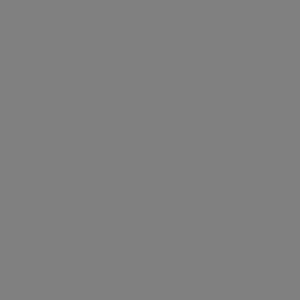

In [36]:
from utils.dicom_helpers import load_medical_image, download_sample_chest_xray
from utils.mcp_tools import analyze_medical_image
from IPython.display import display
import os
from PIL import Image

# Get a sample medical image
sample_image_path = download_sample_chest_xray('/content/sample_data')

# Diagnostic: check file existence and size
if os.path.exists(sample_image_path):
    size = os.path.getsize(sample_image_path)
    print(f'Downloaded file size: {size} bytes')
    if size < 1000:
        print('Warning: File is very small, might be a corrupted download.')

try:
    image, metadata = load_medical_image(sample_image_path)

    print('Image metadata:')
    for k, v in metadata.items():
        print(f'  {k}: {v}')

    # Display
    display(image.resize((300, 300)))
except Exception as e:
    print(f'Failed to load image: {e}')
    print('Falling back to creating a dummy chest X-ray placeholder for the demo...')
    # Fallback: Create a gray placeholder if the download failed
    image = Image.new('RGB', (512, 512), color=(128, 128, 128))
    metadata = {'modality': 'CR', 'body_part': 'CHEST'}
    display(image.resize((300, 300)))

In [38]:
# Build clinical context from prior stages
enc = load_encounter(encounter_id)
soap = enc['stages']['consultation'].get('soap_note', {})
admission = enc['stages']['admission'].get('admission_note', '')

clinical_context = ''
if isinstance(soap, dict):
    clinical_context += f"Assessment: {soap.get('assessment', 'N/A')}\n"
    clinical_context += f"Plan: {soap.get('plan', 'N/A')}\n"
if admission:
    clinical_context += f"\nAdmission Note:\n{str(admission)[:500]}"
if not clinical_context.strip():
    clinical_context = 'Patient with productive cough, fever. Rule out pneumonia.'

modality = metadata.get('modality', 'X-ray')
body_part = metadata.get('body_part', 'Chest')

print('Analyzing medical image with MedGemma...')

# Manual prompt construction to avoid the TypeError in apply_chat_template
prompt = f"Modality: {modality}\nBody Part: {body_part}\nClinical Context: {clinical_context}\n\nPlease provide a radiology report findings and impression."

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ]
    }
]

# Process inputs
inputs = medgemma_processor(text=medgemma_processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False), images=image, return_tensors="pt").to(medgemma_model.device)

with torch.no_grad():
    out = medgemma_model.generate(**inputs, max_new_tokens=512)

# Decode results
radiology_report = medgemma_processor.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

print('\n' + '='*60)
print('RADIOLOGY REPORT')
print('='*60)
print(radiology_report)

# Save
encounter = update_stage(encounter_id, 'radiology', {
    'images': [{'orthanc_id': 'local', 'modality': modality, 'body_part': body_part, 'path': sample_image_path}],
    'reports': [{'findings': radiology_report, 'impression': '', 'recommendations': ''}]
})
print(f'\nRadiology saved to encounter {encounter_id}')

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Analyzing medical image with MedGemma...

RADIOLOGY REPORT
<unused94>thought
Here's a thinking process to construct the admission note based on the provided SOAP note:

1.  **Identify the Core Task:** The goal is to create a hospital admission note from a given SOAP note. This means translating the information from the SOAP note into a structured, formal hospital admission format.

2.  **Analyze the Input (SOAP Note):**
    *   **Patient:** [Patient Name - *Need to make up a plausible name*]
    *   **DOB:** [Patient DOB - *Need to make up a plausible DOB*]
    *   **MRN:** [Patient MRN - *Need to make up a plausible MRN*]
    *   **Admitting Physician:** [Admitting Physician Name - *Need to make up a plausible name*]
    *   **Admitting Diagnosis:** [Admitting Diagnosis - *Need to make up a plausible diagnosis based on the SOAP note*]
    *   **History of Present Illness (HPI):**
        *   Onset: ~3 days ago
        *   Symptoms: Productive cough (yellowish sputum), fever (up to 101

---
## Section 5: Discharge — Aggregate → Summary

In [40]:
import torch
from utils.prompts import DISCHARGE_SYSTEM_PROMPT, DISCHARGE_USER_TEMPLATE

enc = load_encounter(encounter_id)
consultation = enc['stages']['consultation']
admission_stage = enc['stages']['admission']
radiology_stage = enc['stages']['radiology']

# Format SOAP
soap = consultation.get('soap_note', {})
soap_text = ''
if isinstance(soap, dict):
    for s in ['subjective', 'objective', 'assessment', 'plan']:
        if soap.get(s):
            soap_text += f'**{s.title()}:** {soap[s]}\n\n'
if not soap_text.strip():
    soap_text = 'No consultation note.'

# Format vitals
vitals_trend = format_vitals_summary(admission_stage.get('vitals_history', []))

# Format radiology
rad_reports = ''
for i, r in enumerate(radiology_stage.get('reports', []), 1):
    rad_reports += f'Report {i}:\n{r.get("findings", "N/A")}\n\n'
if not rad_reports.strip():
    rad_reports = 'No radiology reports.'

admission_note_text = str(admission_stage.get('admission_note', 'No admission note.'))

print('Generating discharge summary...')

# Manual prompt construction for MedGemma
formatted_user = DISCHARGE_USER_TEMPLATE.format(
    soap_note=soap_text,
    admission_note=admission_note_text,
    vitals_trend=vitals_trend,
    radiology_reports=rad_reports
)

messages = [
    {"role": "system", "content": [{"type": "text", "text": DISCHARGE_SYSTEM_PROMPT}]},
    {"role": "user", "content": [{"type": "text", "text": formatted_user}]}
]

inputs = medgemma_processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors='pt'
).to(medgemma_model.device)

with torch.no_grad():
    out = medgemma_model.generate(**inputs, max_new_tokens=1536)

discharge_summary = medgemma_processor.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

print('\n' + '='*60)
print('DISCHARGE SUMMARY')
print('='*60)
print(discharge_summary)

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Generating discharge summary...

DISCHARGE SUMMARY
<unused94>thought
The user wants me to generate a comprehensive discharge summary based on a provided SOAP note and some additional context (like vital signs and radiology reports).

**Plan:**

1.  **Identify the core information:** Extract the key details from the SOAP note.
    *   Patient Name (make one up)
    *   DOB (make one up)
    *   MRN (make one up)
    *   Admitting Diagnosis (from SOAP note assessment)
    *   History of Present Illness (from SOAP note subjective)
    *   Past Medical History (from SOAP note subjective)
    *   Current Medications (from SOAP note subjective)
    *   Allergies (from SOAP note subjective)
    *   Vital Signs (from SOAP note objective)
    *   Physical Exam Findings (from SOAP note objective)
    *   Assessment (from SOAP note assessment)
    *   Plan (from SOAP note plan)
    *   Active Conditions (from SOAP note assessment)
    *   Active Medications (from SOAP note plan)
    *   Active Or

In [ ]:
# ICD-10 code suggestions
icd10_suggestions = []
diagnosis_map = {
    'pneumonia': {'code': 'J18.9', 'description': 'Pneumonia, unspecified organism'},
    'type 2 diabetes': {'code': 'E11.9', 'description': 'Type 2 diabetes mellitus without complications'},
    'hypertension': {'code': 'I10', 'description': 'Essential (primary) hypertension'},
    'cough': {'code': 'R05.9', 'description': 'Cough, unspecified'},
    'fever': {'code': 'R50.9', 'description': 'Fever, unspecified'},
}

conditions_text = ' '.join(c.get('display', '') for c in admission_stage.get('conditions', []))
combined = (conditions_text + ' ' + str(soap.get('assessment', '')) + ' ' + discharge_summary).lower()

print('ICD-10 Code Suggestions:')
for keyword, code_info in diagnosis_map.items():
    if keyword in combined:
        icd10_suggestions.append(code_info)
        print(f'  {code_info["code"]}: {code_info["description"]}')

# Save discharge
meds_at_discharge = [m.get('display', '') for m in admission_stage.get('medications', []) if m.get('display')]
encounter = update_stage(encounter_id, 'discharge', {
    'summary': discharge_summary,
    'icd10_codes': icd10_suggestions,
    'medications_at_discharge': meds_at_discharge,
    'follow_up': 'Follow-up in 1 week. Return sooner if symptoms worsen.'
})
print(f'\nDischarge saved to encounter {encounter_id}')

---
## Section 6: Complete Encounter Record

In [ ]:
final = load_encounter(encounter_id)
stages = final['stages']

print('='*70)
print(f'COMPLETE ENCOUNTER: {encounter_id}')
print(f'Patient: {final["patient"]["name"]}')
print('='*70)

for stage_name in ['consultation', 'admission', 'radiology', 'discharge']:
    stage = stages[stage_name]
    status = 'COMPLETE' if stage.get('timestamp') else 'MISSING'
    print(f'\n--- {stage_name.upper()} [{status}] ---')
    print(f'  Timestamp: {stage.get("timestamp", "N/A")}')

# Key outputs
print(f'\n--- SOAP Assessment ---')
print(stages['consultation'].get('soap_note', {}).get('assessment', 'N/A')[:300])
print(f'\n--- Discharge Summary (first 500 chars) ---')
print(str(stages['discharge'].get('summary', 'N/A'))[:500])
print(f'\n--- ICD-10 Codes ---')
for code in stages['discharge'].get('icd10_codes', []):
    print(f'  {code["code"]}: {code["description"]}')

In [ ]:
# Export discharge report as Markdown
output_path = f'/content/encounters/{encounter_id}_discharge_report.md'
with open(output_path, 'w') as f:
    f.write(f'# Discharge Report: {encounter_id}\n\n')
    f.write(f'**Patient:** {final["patient"]["name"]}\n')
    f.write(f'**MRN:** {final["patient"]["mrn"]}\n')
    f.write(f'**DOB:** {final["patient"]["dob"]}\n\n---\n\n')
    f.write('## Consultation SOAP Note\n\n')
    s = stages['consultation'].get('soap_note', {})
    if isinstance(s, dict):
        for k, v in s.items():
            if v:
                f.write(f'**{k.title()}:** {v}\n\n')
    f.write('---\n\n## Admission Note\n\n')
    f.write(str(stages['admission'].get('admission_note', 'N/A')) + '\n\n')
    f.write('---\n\n## Radiology Reports\n\n')
    for r in stages['radiology'].get('reports', []):
        f.write(str(r.get('findings', 'N/A')) + '\n\n')
    f.write('---\n\n## Discharge Summary\n\n')
    f.write(str(stages['discharge'].get('summary', 'N/A')) + '\n\n')
    f.write('---\n\n## ICD-10 Codes\n\n')
    for c in stages['discharge'].get('icd10_codes', []):
        f.write(f'- **{c["code"]}**: {c["description"]}\n')

print(f'Discharge report: {output_path}')
print(f'Encounter JSON: /content/encounters/{encounter_id}.json')
print('\nFull pipeline complete!')